In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)


labels = mnist.target.astype(int)       

data = np.column_stack([labels, mnist.data])   

np.random.shuffle(data)

m, n = data.shape                      

data_dev   = data[0:1000].T             
Y_dev      = data_dev[0].astype(int)   
X_dev      = data_dev[1:] / 255.0       

data_train = data[1000:m].T             
Y_train    = data_train[0].astype(int)  
X_train    = data_train[1:] / 255.0   

print(Y_train[:10])        
print(Y_train.max())   
print(X_train.max())       
print(X_train.shape)       

[7 2 3 4 0 6 0 6 6 9]
9
1.0
(784, 69000)


In [12]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) 
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

_,m_train = X_train.shape

In [13]:
def init_params():
    W1 = np.random.randn(10, 784) * 0.01   
    b1 = np.zeros((10, 1))                  
    W2 = np.random.randn(10, 10)  * 0.01   
    b2 = np.zeros((10, 1))                  
    return W1, b1, W2, b2
    
def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z = Z - np.max(Z, axis = 0, keepdims = True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis = 0, keepdims = True)
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

In [14]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)   
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True) 
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2   

    return W1, b1, W2, b2

In [15]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 100 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [16]:
W1, b1, W2, b2 = gradient_descent(X_train.astype(np.float32)/255.0, Y_train.astype(np.int32), 0.1, 500)

Iteration:  0
[3 1 6 ... 2 0 5] [5 7 9 ... 2 5 9]
0.12885507246376812
Iteration:  100
[0 0 1 ... 2 0 4] [5 7 9 ... 2 5 9]
0.5040289855072464
Iteration:  200
[5 0 9 ... 2 0 9] [5 7 9 ... 2 5 9]
0.813695652173913
Iteration:  300
[5 0 9 ... 2 0 9] [5 7 9 ... 2 5 9]
0.8624782608695652
Iteration:  400
[5 0 9 ... 2 0 9] [5 7 9 ... 2 5 9]
0.8797971014492754


In [17]:
def make_predictions(X, W1, b1, W2, b2):
    X = np.array(X, dtype=np.float32)
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    current_image = np.array(current_image, dtype=np.float32)
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    plt.gray()
    plt.imshow(current_image.reshape(28,28), interpolation='nearest')
    plt.show()

Prediction:  [5]
Label:  5


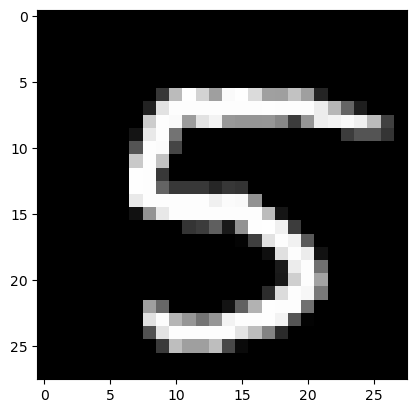

Prediction:  [0]
Label:  7


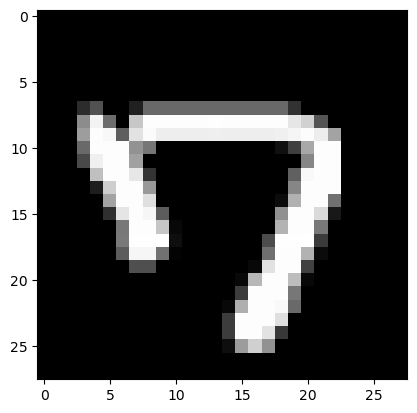

Prediction:  [9]
Label:  9


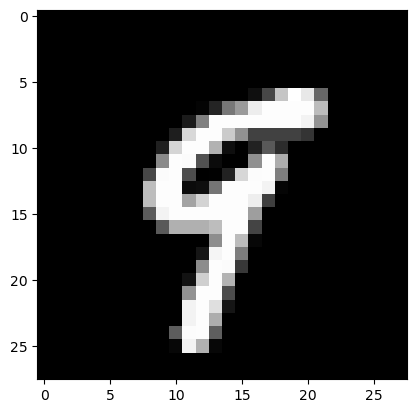

Prediction:  [5]
Label:  5


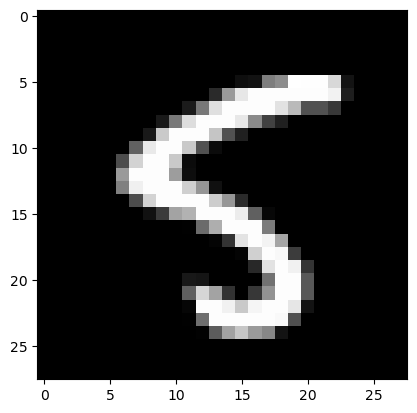

In [18]:
for i in range(4):
    test_prediction(i, W1, b1, W2, b2)